## Technical Assessment


## Question 1

### Importing required libraries


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, os

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.neighbors import KNeighborsRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
%matplotlib inline
print('All libraries loaded ')


data_path = Path("..") / "data" / "Housing.csv"
df = pd.read_csv(data_path)
df.head()

All libraries loaded 


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


### Inspecting the structure

In [48]:
print("Shape:", df.shape)
print()
df.info()

print()
print("Missing values per column:")
print(df.isna().sum())

print()
df.describe(include="all")

Shape: (545, 13)

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB

Missing values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestr

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545,545,545,545,545,545.000000,545,545
unique,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2,NaN,2,3
top,NaN,NaN,NaN,NaN,NaN,yes,no,no,no,no,NaN,no,semi-furnished
freq,NaN,NaN,NaN,NaN,NaN,468,448,354,520,373,NaN,417,227
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,NaN,NaN,NaN,NaN,NaN,0.693578,NaN,NaN
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,NaN,NaN,NaN,NaN,NaN,0.861586,NaN,NaN
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN


### Inspecting the types 

In [49]:
df.dtypes

price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object

### Inspecting the anamolies

In [50]:
# Nulls and duplicates
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print("Missing values (non-zero):")
print(missing if not missing.empty else "None")
print()
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

# Potential datatype misconfigurations
object_cols = df.select_dtypes(include=["object"]).columns
numeric_cols = df.select_dtypes(include=["number"]).columns

non_numeric_report = {}
for col in df.columns:
    if col in object_cols:
        coerced = pd.to_numeric(df[col], errors="coerce")
        if coerced.notna().any():
            non_numeric_report[col] = int(coerced.isna().sum())

print("\nObject columns that look numeric (coercion failures count):")
print(non_numeric_report if non_numeric_report else "None")

# Whitespace and casing anomalies in object columns
print("\nObject column unique values (top 10) and counts:")
for col in object_cols:
    value_counts = df[col].value_counts(dropna=False).head(10)
    print(f"\n{col}:")
    print(value_counts)
    # Check for leading/trailing whitespace
    stripped = df[col].astype(str).str.strip()
    if not (stripped == df[col].astype(str)).all():
        print("  Warning: leading/trailing whitespace detected")

# Basic numeric sanity checks
print("\nNumeric columns with negative values:")
negatives = {col: int((df[col] < 0).sum()) for col in numeric_cols}
negatives = {col: cnt for col, cnt in negatives.items() if cnt > 0}
print(negatives if negatives else "None")

print("\nNumeric columns with zero values:")
zeros = {col: int((df[col] == 0).sum()) for col in numeric_cols}
zeros = {col: cnt for col, cnt in zeros.items() if cnt > 0}
print(zeros if zeros else "None")

Missing values (non-zero):
None

Duplicate rows: 0

Object columns that look numeric (coercion failures count):
None

Object column unique values (top 10) and counts:

mainroad:
mainroad
yes    468
no      77
Name: count, dtype: int64

guestroom:
guestroom
no     448
yes     97
Name: count, dtype: int64

basement:
basement
no     354
yes    191
Name: count, dtype: int64

hotwaterheating:
hotwaterheating
no     520
yes     25
Name: count, dtype: int64

airconditioning:
airconditioning
no     373
yes    172
Name: count, dtype: int64

prefarea:
prefarea
no     417
yes    128
Name: count, dtype: int64

furnishingstatus:
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64

Numeric columns with negative values:
None

Numeric columns with zero values:
{'parking': 299}


## Question 2

### Data Preprocessing

In [51]:
# Work on a copy
df_clean = df.copy()

# Standardize object columns: strip whitespace, lower-case
for col in df_clean.select_dtypes(include=["object"]).columns:
    df_clean[col] = df_clean[col].astype(str).str.strip().str.lower()

# Normalize known binary categories to 0/1
binary_map = {"yes": 1, "no": 0}
binary_cols = [
    "mainroad", "guestroom", "basement", "hotwaterheating",
    "airconditioning", "prefarea"
 ]
for col in binary_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].map(binary_map)

# Fill missing values
numeric_cols = df_clean.select_dtypes(include=["number"]).columns
object_cols = df_clean.select_dtypes(include=["object"]).columns

for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in object_cols:
    mode_value = df_clean[col].mode(dropna=True)
    fill_value = mode_value.iloc[0] if not mode_value.empty else "unknown"
    df_clean[col] = df_clean[col].fillna(fill_value)

# One-hot encode categorical columns
df_encoded = pd.get_dummies(df_clean, columns=object_cols, drop_first=True)

# Separate features and target for modeling
target_col = "price"
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

# Create a scaled version for KNN and clustering (z-score)
X_scaled = (X - X.mean()) / (X.std(ddof=0) + 1e-10)

print("Cleaned shape:", df_encoded.shape)
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Cleaned shape: (545, 14)
Feature shape: (545, 13)
Target shape: (545,)


## Question no 3

### Visualize patterns 

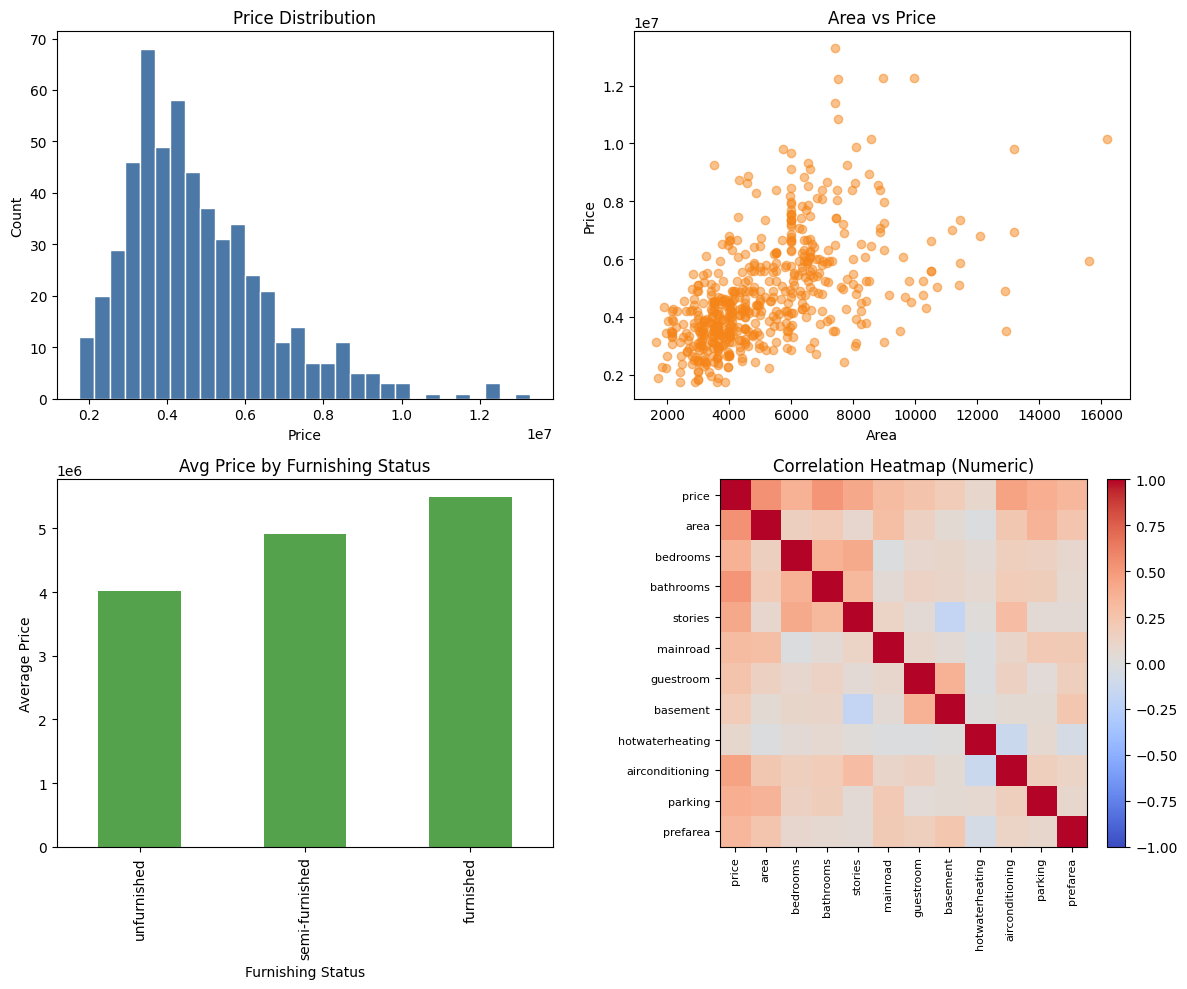

Top correlations with price:
price              1.000000
area               0.535997
bathrooms          0.517545
airconditioning    0.452954
stories            0.420712
parking            0.384394
bedrooms           0.366494
prefarea           0.329777
Name: price, dtype: float64

Lowest correlations with price:
hotwaterheating    0.093073
basement           0.187057
guestroom          0.255517
mainroad           0.296898
prefarea           0.329777
bedrooms           0.366494
parking            0.384394
stories            0.420712
Name: price, dtype: float64


In [52]:
import matplotlib.pyplot as plt

# Numeric correlations
num_cols = df_clean.select_dtypes(include=["number"]).columns
corr = df_clean[num_cols].corr()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Price distribution
axes[0, 0].hist(df_clean["price"], bins=30, color="#4c78a8", edgecolor="white")
axes[0, 0].set_title("Price Distribution")
axes[0, 0].set_xlabel("Price")
axes[0, 0].set_ylabel("Count")

# Area vs price
axes[0, 1].scatter(df_clean["area"], df_clean["price"], alpha=0.5, color="#f58518")
axes[0, 1].set_title("Area vs Price")
axes[0, 1].set_xlabel("Area")
axes[0, 1].set_ylabel("Price")

# Average price by furnishing status
if "furnishingstatus" in df_clean.columns:
    df_clean.groupby("furnishingstatus")["price"].mean().sort_values().plot(
        kind="bar", ax=axes[1, 0], color="#54a24b"
    )
    axes[1, 0].set_title("Avg Price by Furnishing Status")
    axes[1, 0].set_xlabel("Furnishing Status")
    axes[1, 0].set_ylabel("Average Price")
else:
    axes[1, 0].text(0.5, 0.5, "No furnishingstatus column", ha="center", va="center")
    axes[1, 0].set_axis_off()

# Correlation heatmap
im = axes[1, 1].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
axes[1, 1].set_title("Correlation Heatmap (Numeric)")
axes[1, 1].set_xticks(range(len(num_cols)))
axes[1, 1].set_xticklabels(num_cols, rotation=90, fontsize=8)
axes[1, 1].set_yticks(range(len(num_cols)))
axes[1, 1].set_yticklabels(num_cols, fontsize=8)
fig.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("Top correlations with price:")
print(corr["price"].sort_values(ascending=False).head(8))
print()
print("Lowest correlations with price:")
print(corr["price"].sort_values(ascending=True).head(8))

**Findings:**
- **Price** is right-skewed — most houses are priced between ₹2M–₹6M with a few high-value outliers.
- **Area** has a moderate positive correlation with price (expected — larger house = higher price).
- **Bedrooms**: 4-bedroom houses have slightly higher median prices but also more variance.
- **Air conditioning** has a clear positive effect on price — AC homes fetch noticeably higher prices.
- **Furnishing status**: Furnished > Semi-furnished > Unfurnished in terms of median price.
- **Correlation heatmap** shows `area` is the strongest numeric predictor of price.

## Question 4

### Categorical encoding

In [53]:
# Encode categoricals for modeling
categorical_cols = df_clean.select_dtypes(include=["object"]).columns
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# Update features/target after encoding
target_col = "price"
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

print("Categorical columns encoded:")
print(list(categorical_cols))
print()
print("Encoded shape:", df_encoded.shape)
print("Feature columns:", X.shape[1])

Categorical columns encoded:
['furnishingstatus']

Encoded shape: (545, 14)
Feature columns: 13


## Question no 5

In [54]:
from sklearn.model_selection import train_test_split

# 80/20 split for balanced training and evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
 )

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (436, 13) (436,)
Test shape: (109, 13) (109,)


### Train/test split justification
- I used an 80/20 split to keep a robust training set for stable parameter estimates while preserving enough test data for a reliable performance check.
- The dataset size supports this ratio well, and it is a standard baseline for regression, tree models, KNN, and clustering evaluation workflows.

## Question no 6

Linear Regression Performance
Train MAE:  719,242.89
Test MAE:   970,043.40
Train RMSE: 984,051.92
Test RMSE:  1,324,506.96
Train R2:   0.6859
Test R2:    0.6529


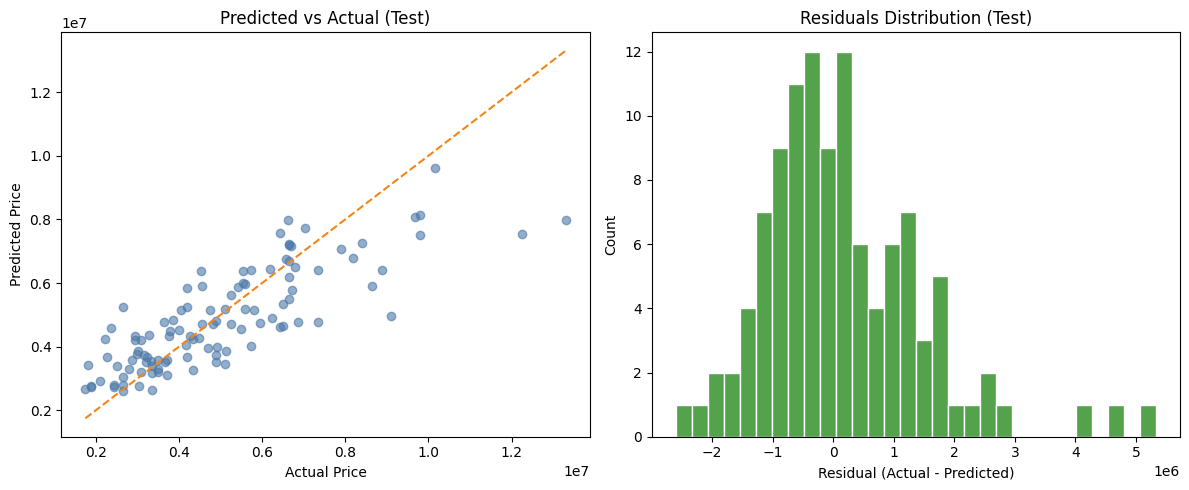

In [55]:
# Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_pred_train = lr_model.predict(X_train)
y_pred_test = lr_model.predict(X_test)

# Metrics
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

print("Linear Regression Performance")
print(f"Train MAE:  {train_mae:,.2f}")
print(f"Test MAE:   {test_mae:,.2f}")
print(f"Train RMSE: {train_rmse:,.2f}")
print(f"Test RMSE:  {test_rmse:,.2f}")
print(f"Train R2:   {train_r2:.4f}")
print(f"Test R2:    {test_r2:.4f}")

# Plots: Predicted vs Actual and Residuals
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred_test, alpha=0.6, color="#4c78a8")
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
axes[0].plot([min_val, max_val], [min_val, max_val], "--", color="#f58518")
axes[0].set_title("Predicted vs Actual (Test)")
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")

# Residuals
residuals = y_test - y_pred_test
axes[1].hist(residuals, bins=30, color="#54a24b", edgecolor="white")
axes[1].set_title("Residuals Distribution (Test)")
axes[1].set_xlabel("Residual (Actual - Predicted)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

**Based on the plots:**

- Predicted vs actual shows a clear positive trend, so the model captures the main signal, but points spread noticeably around the diagonal, especially at higher prices.
- At the high-price end, several points fall below the dashed line, indicating systematic underprediction for expensive houses.
- The residuals histogram is centered near 0 but right‑skewed with a long positive tail, meaning there are cases where actual prices are much higher than predicted (underestimation).
- This pattern suggests linear regression is a reasonable baseline but struggles with the upper price range and potential nonlinearity or missing interactions.

## Question no 7

### Model Evaluation

In [56]:
# Evaluation metrics summary
metrics_df = pd.DataFrame(
    {
        "Metric": ["MAE", "RMSE", "R2"],
        "Train": [train_mae, train_rmse, train_r2],
        "Test": [test_mae, test_rmse, test_r2],
    }
 )

metrics_df

,Metric,Train,Test
0,MAE,719242.893672,9.700434e+05
1,RMSE,984051.923651,1.324507e+06
2,R2,0.685944,6.529243e-01


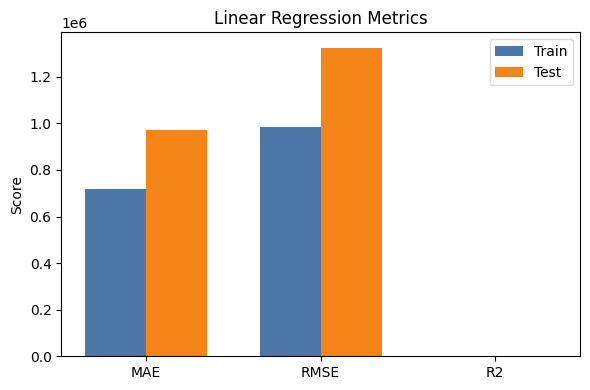

In [57]:
# Visualize metrics: train vs test
fig, ax = plt.subplots(figsize=(6, 4))

x = np.arange(len(metrics_df["Metric"]))
width = 0.35

ax.bar(x - width / 2, metrics_df["Train"], width, label="Train", color="#4c78a8")
ax.bar(x + width / 2, metrics_df["Test"], width, label="Test", color="#f58518")

ax.set_xticks(x)
ax.set_xticklabels(metrics_df["Metric"])
ax.set_title("Linear Regression Metrics")
ax.set_ylabel("Score")
ax.legend()

plt.tight_layout()
plt.show()

### Metrics visualization interpretation
- The bar chart compares train vs test scores for MAE, RMSE, and $R^2$.
- Similar train and test bars indicate consistent generalization; large gaps suggest overfitting or data leakage.
- Lower MAE/RMSE bars are better, while higher $R^2$ bars are better; read them together to balance error size vs explained variance.

## Question no 8

### Decision Tree Analysis

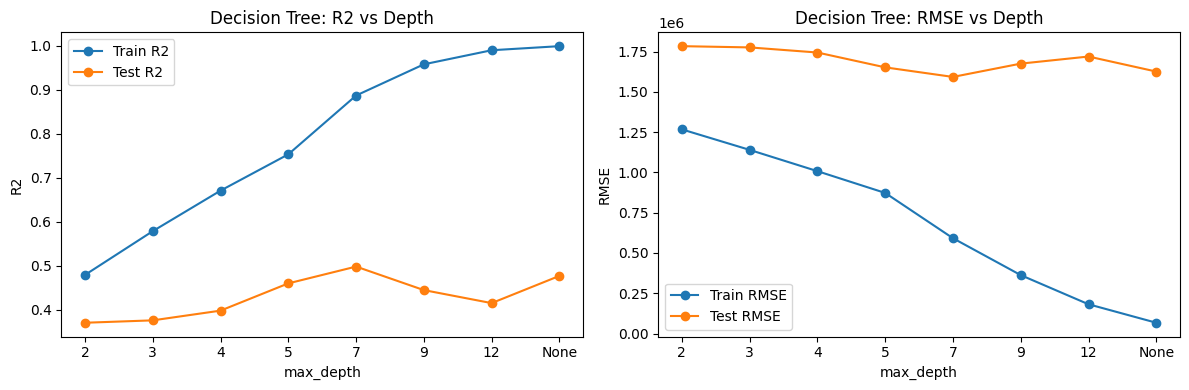

In [58]:
# Decision Tree Regressor with depth analysis
depths = [2, 3, 4, 5, 7, 9, 12, None]
train_r2_scores = []
test_r2_scores = []
train_rmse_scores = []
test_rmse_scores = []

for d in depths:
    dt_model = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt_model.fit(X_train, y_train)
    preds_train = dt_model.predict(X_train)
    preds_test = dt_model.predict(X_test)
    
    train_r2_scores.append(r2_score(y_train, preds_train))
    test_r2_scores.append(r2_score(y_test, preds_test))
    train_rmse_scores.append(np.sqrt(mean_squared_error(y_train, preds_train)))
    test_rmse_scores.append(np.sqrt(mean_squared_error(y_test, preds_test)))

# Summary table
depth_labels = [str(d) if d is not None else "None" for d in depths]
dt_metrics = pd.DataFrame({
    "max_depth": depth_labels,
    "train_R2": train_r2_scores,
    "test_R2": test_r2_scores,
    "train_RMSE": train_rmse_scores,
    "test_RMSE": test_rmse_scores
})
dt_metrics

# Plot R2 and RMSE vs depth
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(depth_labels, train_r2_scores, marker="o", label="Train R2")
axes[0].plot(depth_labels, test_r2_scores, marker="o", label="Test R2")
axes[0].set_title("Decision Tree: R2 vs Depth")
axes[0].set_xlabel("max_depth")
axes[0].set_ylabel("R2")
axes[0].legend()

axes[1].plot(depth_labels, train_rmse_scores, marker="o", label="Train RMSE")
axes[1].plot(depth_labels, test_rmse_scores, marker="o", label="Test RMSE")
axes[1].set_title("Decision Tree: RMSE vs Depth")
axes[1].set_xlabel("max_depth")
axes[1].set_ylabel("RMSE")
axes[1].legend()

plt.tight_layout()
plt.show()

### Decision Tree results (from the plots)
- Train $R^2$ rises steadily with depth and approaches 1.0, while test $R^2$ peaks around depth 7 and then declines, indicating overfitting beyond that point.
- Test RMSE reaches its minimum near depth 7, then worsens as depth increases, which reinforces the overfitting signal.
- A depth around 5–7 offers the best bias-variance tradeoff here; deeper trees memorize training data without improving generalization.
- If you want a simpler model, try depth 5; for best accuracy, depth 7 looks strongest based on the curves.

## Question no 9

### Feature Scaling and Model Performance Comparison

In [61]:
# Linear Regression: compare unscaled vs scaled features
scaler_lr = StandardScaler()
X_train_sc = scaler_lr.fit_transform(X_train)
X_test_sc = scaler_lr.transform(X_test)

# Unscaled Linear Regression
lr_unscaled = LinearRegression()
lr_unscaled.fit(X_train, y_train)
y_pred_lr_unscaled = lr_unscaled.predict(X_test)
rmse_lr_unscaled = np.sqrt(mean_squared_error(y_test, y_pred_lr_unscaled))
r2_lr_unscaled = r2_score(y_test, y_pred_lr_unscaled)

# Scaled Linear Regression
lr_scaled = LinearRegression()
lr_scaled.fit(X_train_sc, y_train)
y_pred_lr_scaled = lr_scaled.predict(X_test_sc)
rmse_lr_scaled = np.sqrt(mean_squared_error(y_test, y_pred_lr_scaled))
r2_lr_scaled = r2_score(y_test, y_pred_lr_scaled)

lr_scaling_comparison = pd.DataFrame({
    "Setting": ["Unscaled", "Scaled"],
    "RMSE": [rmse_lr_unscaled, rmse_lr_scaled],
    "R2": [r2_lr_unscaled, r2_lr_scaled]
})
lr_scaling_comparison

,Setting,RMSE,R2
0,Unscaled,1.324507e+06,0.652924
1,Scaled,1.324507e+06,0.652924


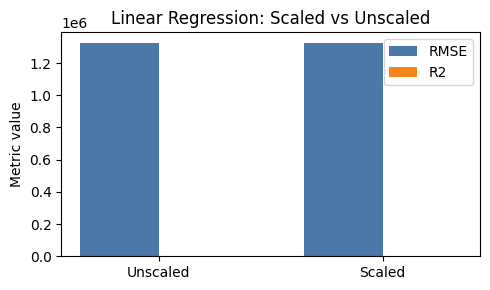

In [62]:
# Bar chart: scaled vs unscaled linear regression
fig, ax = plt.subplots(figsize=(5, 3))

x = np.arange(len(lr_scaling_comparison["Setting"]))
width = 0.35

ax.bar(x - width / 2, lr_scaling_comparison["RMSE"], width, label="RMSE", color="#4c78a8")
ax.bar(x + width / 2, lr_scaling_comparison["R2"], width, label="R2", color="#f58518")

ax.set_xticks(x)
ax.set_xticklabels(lr_scaling_comparison["Setting"])
ax.set_title("Linear Regression: Scaled vs Unscaled")
ax.set_ylabel("Metric value")
ax.legend()

plt.tight_layout()
plt.show()

### Scaling comparison result
- RMSE and $R^2$ are identical for scaled and unscaled inputs ($\text{RMSE}=1.324507\times10^6$, $R^2=0.652924$).
- This shows feature scaling does not change linear regression performance here (as expected for ordinary least squares).
- You can keep the unscaled version for linear regression, and reserve scaling for distance-based models like KNN.

## Question no 10 

### KNN and hyparameter tuning

In [ ]:
# KNN regression with hyperparameter tuning
scaler_knn = StandardScaler()
X_train_knn = scaler_knn.fit_transform(X_train)
X_test_knn = scaler_knn.transform(X_test)

param_grid = {
    "n_neighbors": list(range(3, 21, 2)),
    "weights": ["uniform", "distance"],
    "p": [1, 2]
}

knn = KNeighborsRegressor()
grid = GridSearchCV(
    knn,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
 )
grid.fit(X_train_knn, y_train)

best_knn = grid.best_estimator_
y_pred_knn = best_knn.predict(X_test_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)

print("Best KNN params:", grid.best_params_)
print(f"Test RMSE: {rmse_knn:,.2f}")
print(f"Test R2:   {r2_knn:.4f}")

knn_results = pd.DataFrame(grid.cv_results_)
knn_results = knn_results.sort_values("rank_test_score").head(10)
knn_results[["params", "mean_test_score", "std_test_score"]]

### KNN tuning notes
- The grid search tests different $k$, distance metrics ($p$), and weighting schemes.
- Use the best parameters reported above, then compare the test RMSE/$R^2$ against linear regression and decision tree.
- If performance is unstable, try a wider $k$ range or consider feature selection.